# 🇹🇷 Türkçe Metinlerde Üç Sınıflı Duygu Analizi Hattı


**Yapay Zeka Staj Projesi**

Bu çalışma, TRSAv1 veri seti üzerinde Naive Bayes, Lojistik Regresyon ve SVM algoritmalarını kullanarak Pozitif, Negatif ve Nötr sınıflarını tahmin eden uçtan uca (end-to-end) bir NLP hattı (pipeline) içerir.


**Kullanım:** Hücreleri sırayla çalıştırın (her hücrenin solundaki ▶️
butonuna basın veya `Shift+Enter`). Tüm süreç yaklaşık 3-5 dakika sürer.

**Veri Seti:** [TRSAv1](https://huggingface.co/datasets/maydogan/Turkish_SentimentAnalysis_TRSAv1) — 150.000 örnek; Pozitif/Negatif/Nötr sınıflarının her birinde tam 50.000 örnek (dengeli).

## 1. Kurulum

In [1]:
!pip install -q datasets wordcloud tabulate

import nltk
nltk.download('stopwords')

print("Kurulum tamamlandı.")

Kurulum tamamlandı.


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


## 2. Veri Setini İndirme (TRSAv1)

In [2]:
import pandas as pd
from datasets import load_dataset

print("TRSAv1 veri seti indiriliyor (Hugging Face: maydogan/Turkish_SentimentAnalysis_TRSAv1)...")
dataset = load_dataset("maydogan/Turkish_SentimentAnalysis_TRSAv1")
df = dataset["train"].to_pandas()

print(f"Toplam örnek: {len(df):,}")
print(f"Sütunlar: {list(df.columns)}")
df.head()

TRSAv1 veri seti indiriliyor (Hugging Face: maydogan/Turkish_SentimentAnalysis_TRSAv1)...


Toplam örnek: 150,000
Sütunlar: ['id', 'score', 'review']


,id,score,review
0,0,Positive,Kokusu çok güzel etkisi de efsane
1,1,Negative,hiç bir fark olmadı siyah nokta silmedi
2,2,Positive,şeffaf güzel bir krem elimi yumuşacık yaptı
3,3,Positive,Özellikle karma ve hassas cildiniz varsa La Ro...
4,4,Negative,çok iyi nemlendiriyor ama daha ucuz muadilleri...


## 3. Keşifsel Veri Analizi (EDA)


Veri seti içindeki sınıf dağılımlarının dengesi (class imbalance kontrolü) ve metinlerin karakter uzunluk anomalileri incelenmiştir.

Eksik değer sayısı: 0
Yinelenen satır sayısı: 9020

Sınıf dağılımı:
score
Positive    50000
Negative    50000
Neutral     50000
Name: count, dtype: int64


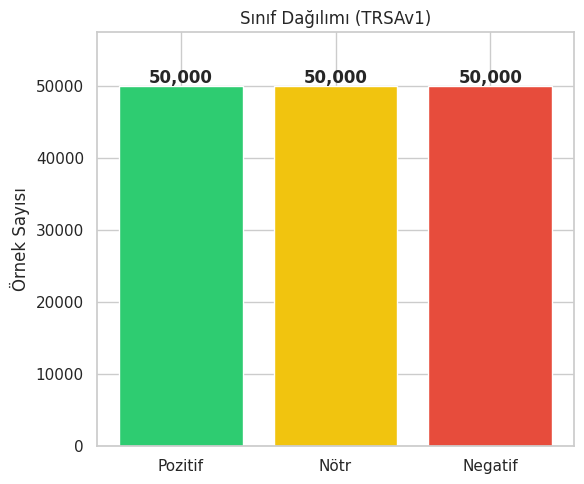

In [3]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
COLORS = {"Positive": "#2ecc71", "Negative": "#e74c3c", "Neutral": "#f1c40f"}
LABELS_TR = {"Positive": "Pozitif", "Negative": "Negatif", "Neutral": "Nötr"}
order = ["Positive", "Neutral", "Negative"]

print("Eksik değer sayısı:", df.isnull().sum().sum())
print("Yinelenen satır sayısı:", df.duplicated(subset=["review"]).sum())
print("\nSınıf dağılımı:")
print(df["score"].value_counts())

class_counts = df["score"].value_counts().reindex(order)
plt.figure(figsize=(6, 5))
bars = plt.bar([LABELS_TR[c] for c in order], class_counts.values, color=[COLORS[c] for c in order])
plt.title("Sınıf Dağılımı (TRSAv1)")
plt.ylabel("Örnek Sayısı")
for b, v in zip(bars, class_counts.values):
    plt.text(b.get_x() + b.get_width() / 2, v + 500, f"{v:,}", ha="center", fontweight="bold")
plt.ylim(0, max(class_counts.values) * 1.15)
plt.tight_layout()
plt.show()

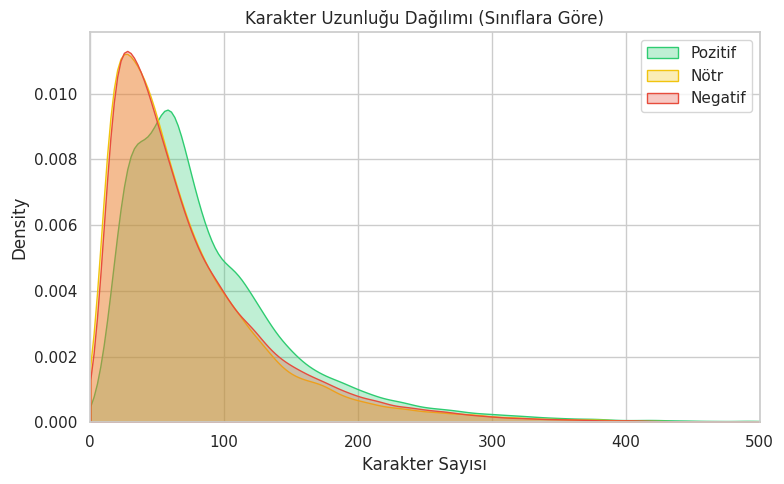

,count,mean,std,min,25%,50%,75%,max
score,,,,,,,,
Negative,50000.0,77.1,69.7,3.0,31.0,56.0,100.0,1458.0
Neutral,50000.0,74.5,70.0,3.0,30.0,54.0,96.0,1993.0
Positive,50000.0,92.9,77.0,5.0,45.0,71.0,117.0,1433.0


In [6]:
df["review"] = df["review"].astype(str)
df["char_len"] = df["review"].str.len()

plt.figure(figsize=(8, 5))
for c in order:
    sns.kdeplot(df[df["score"] == c]["char_len"], label=LABELS_TR[c], color=COLORS[c], fill=True, alpha=0.3, clip=(0, 500))
plt.title("Karakter Uzunluğu Dağılımı (Sınıflara Göre)")
plt.xlabel("Karakter Sayısı")
plt.xlim(0, 500)
plt.legend()
plt.tight_layout()
plt.show()

df.groupby("score")["char_len"].describe().round(1)

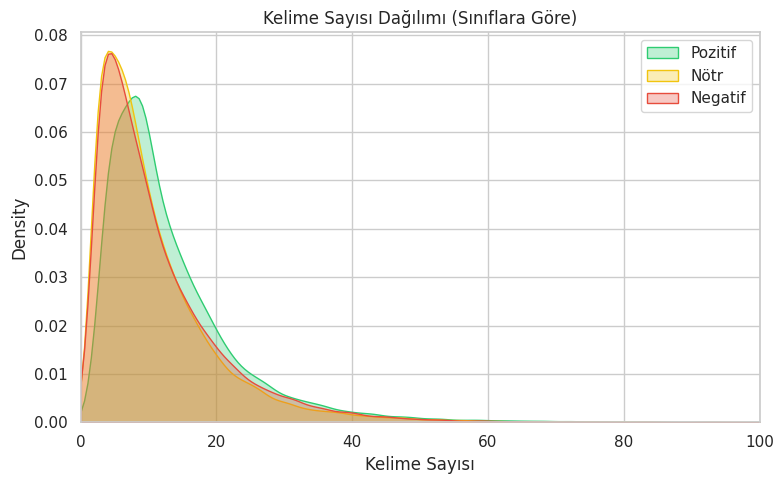


--- Kelime Sayısı İstatistikleri ---


,count,mean,std,min,25%,50%,75%,max
score,,,,,,,,
Negative,50000.0,11.5,10.1,1.0,5.0,8.0,15.0,209.0
Neutral,50000.0,11.0,10.0,1.0,5.0,8.0,14.0,283.0
Positive,50000.0,13.4,10.8,1.0,7.0,10.0,17.0,207.0


In [11]:
# Metindeki kelimeleri boşluklardan ayırarak kelime sayısını hesaplar
df["word_count"] = df["review"].apply(lambda x: len(x.split()))

plt.figure(figsize=(8, 5))
for c in order:
    # Karakter sayısına göre kelime sayısı daha küçük olacağı için clip (sınır) değerini 0 ile 100 kelime yapıyoruz
    sns.kdeplot(df[df["score"] == c]["word_count"], label=LABELS_TR[c], color=COLORS[c], fill=True, alpha=0.3, clip=(0, 100))
plt.title("Kelime Sayısı Dağılımı (Sınıflara Göre)")
plt.xlabel("Kelime Sayısı")
plt.xlim(0, 100) # Grafiğin elindeki görsel gibi net durması için odağı 0-100 kelime yapıyoruz
plt.legend()
plt.tight_layout()
plt.show()

print("\n--- Kelime Sayısı İstatistikleri ---")
df.groupby("score")["word_count"].describe().round(1)

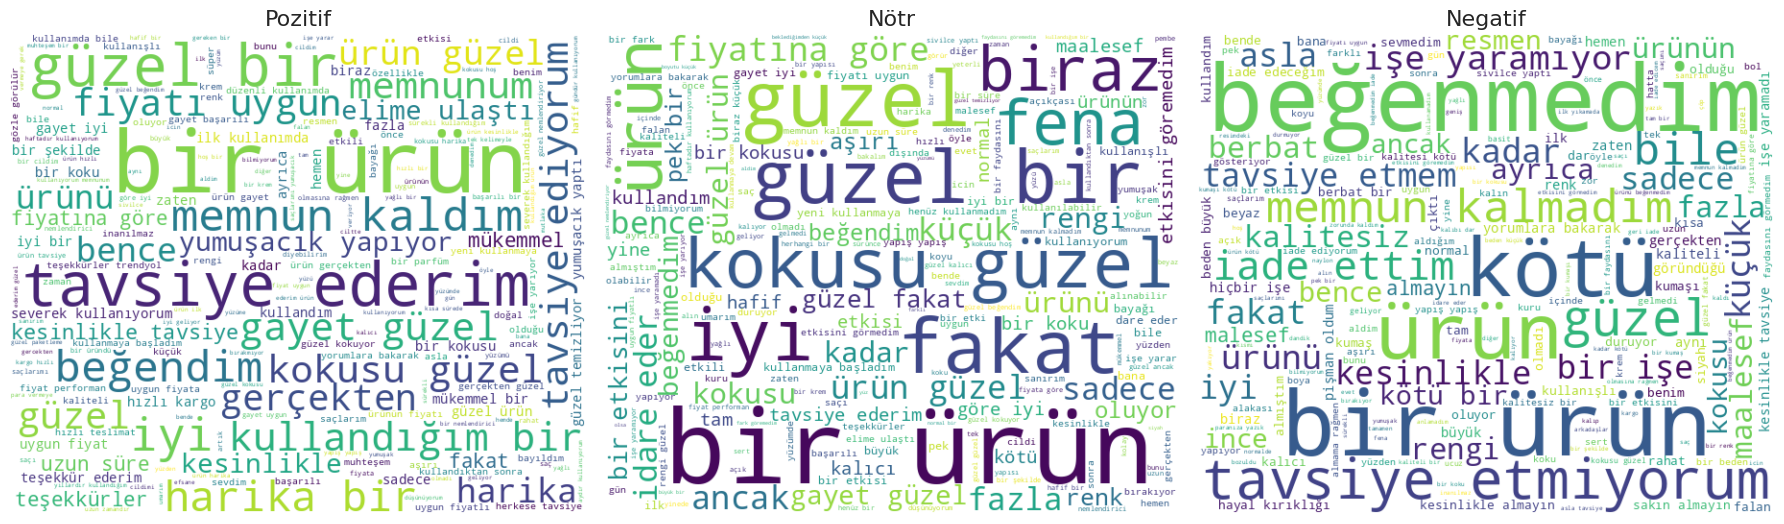

In [12]:
import re
from wordcloud import WordCloud

_wc_stop = {
    "acaba","ama","aslında","az","bazı","belki","biri","birkaç","biz","bu",
    "çok","çünkü","da","daha","de","defa","diye","eğer","en","gibi","hem",
    "hep","hepsi","her","hiç","için","ile","ise","kez","ki","kim","mı","mu",
    "mü","nasıl","ne","neden","nerde","nerede","niçin","niye","o","sanki",
    "şey","siz","şu","tüm","ve","veya","ya","yani","olarak","olan","oldu",
    "olur","üzerine","var","yok","değil","böyle","şöyle","onun","bunun",
    "ben","sen","aldım","geldi",
}

def clean_for_wordcloud(text):
    text = str(text).lower()
    text = re.sub(r"http\S+|www\.\S+", " ", text)
    text = re.sub(r"[^a-zçğıöşü\s]", " ", text)
    words = [w for w in text.split() if w not in _wc_stop and len(w) > 2]
    return " ".join(words)

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
for ax, c in zip(axes, order):
    text = " ".join(df[df["score"] == c]["review"].apply(clean_for_wordcloud))
    wc = WordCloud(width=600, height=500, background_color="white", colormap="viridis").generate(text)
    ax.imshow(wc, interpolation="bilinear")
    ax.set_title(LABELS_TR[c], fontsize=16)
    ax.axis("off")
plt.tight_layout()
plt.show()

## 4. Veri Temizleme (Ön İşleme)

Metin verisindeki gürültülerin (URL, Email, Hashtag) temizlenmesi, stop-words eliminasyonu ve Türkçe karakter duyarlı (İ/i, I/ı) normalizasyon adımları.

In [13]:
from nltk.corpus import stopwords

BASE_STOPWORDS = set(stopwords.words("turkish"))
EXTRA_STOPWORDS = {
    "bir", "de", "da", "ki", "mi", "mı", "mu", "mü", "çok", "daha", "en",
    "gibi", "ile", "için", "ve", "veya", "ya", "ama", "fakat", "ancak",
    "bu", "şu", "o", "her", "hiç", "tüm", "kadar", "diye", "acaba",
    "belki", "yani", "işte", "artık", "yine", "bile", "üzere",
}
TURKISH_STOPWORDS = BASE_STOPWORDS | EXTRA_STOPWORDS

_URL_RE = re.compile(r"https?://\S+|www\.\S+")
_EMAIL_RE = re.compile(r"\S+@\S+")
_MENTION_HASHTAG_RE = re.compile(r"[@#]\w+")
_NON_TURKISH_LETTER_RE = re.compile(r"[^a-zçğıöşü\s]")
_MULTI_SPACE_RE = re.compile(r"\s+")


def turkish_lower(text):
    text = text.replace("İ", "i").replace("I", "ı")
    return text.lower()


def clean_text(text, remove_stopwords=True, min_word_len=2):
    if not isinstance(text, str):
        return ""
    text = turkish_lower(text)
    text = _URL_RE.sub(" ", text)
    text = _EMAIL_RE.sub(" ", text)
    text = _MENTION_HASHTAG_RE.sub(" ", text)
    text = _NON_TURKISH_LETTER_RE.sub(" ", text)
    text = _MULTI_SPACE_RE.sub(" ", text).strip()
    tokens = text.split()
    tokens = [t for t in tokens if len(t) >= min_word_len]
    if remove_stopwords:
        tokens = [t for t in tokens if t not in TURKISH_STOPWORDS]
    return " ".join(tokens)


# Örnek test
for s in ["Bu ürünü ÇOK beğendim, kesinlikle tavsiye ederim!!", "Hiç memnun kalmadım, kötü bir ürün."]:
    print(f"Orijinal: {s}")
    print(f"Temiz   : {clean_text(s)}\n")

Orijinal: Bu ürünü ÇOK beğendim, kesinlikle tavsiye ederim!!
Temiz   : ürünü beğendim kesinlikle tavsiye ederim

Orijinal: Hiç memnun kalmadım, kötü bir ürün.
Temiz   : memnun kalmadım kötü ürün



In [14]:
from tqdm.auto import tqdm
from sklearn.model_selection import train_test_split

df = df.drop_duplicates(subset=["review"]).reset_index(drop=True)
print(f"Yinelenenler çıkarıldıktan sonra: {len(df):,}")

tqdm.pandas(desc="Metinler temizleniyor")
df["clean_review"] = df["review"].progress_apply(clean_text)

before = len(df)
df = df[df["clean_review"].str.strip().str.len() > 0].reset_index(drop=True)
print(f"Boşalan {before - len(df)} satır çıkarıldı. Kalan: {len(df):,}")

label_map = {"Negative": 0, "Neutral": 1, "Positive": 2}
df["label"] = df["score"].map(label_map)

train_df, test_df = train_test_split(
    df, test_size=0.2, random_state=42, stratify=df["label"]
)
print(f"\nEğitim seti: {len(train_df):,} | Test seti: {len(test_df):,}")

Yinelenenler çıkarıldıktan sonra: 140,980


Metinler temizleniyor:   0%|          | 0/140980 [00:00<?, ?it/s]

Boşalan 47 satır çıkarıldı. Kalan: 140,933

Eğitim seti: 112,746 | Test seti: 28,187


## 5. Öznitelik Çıkarımı (TF-IDF) ve Model Eğitimi

TF-IDF öznitelik matrisi (1,2 gram) üzerinden baseline ve lineer modellerin eğitilmesi ve performans metriklerinin çıkarılması.

In [15]:
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer(max_features=30000, ngram_range=(1, 2), min_df=2, sublinear_tf=True)
X_train = vectorizer.fit_transform(train_df["clean_review"])
X_test = vectorizer.transform(test_df["clean_review"])
y_train, y_test = train_df["label"].values, test_df["label"].values

print(f"Öznitelik sayısı: {X_train.shape[1]:,}")

Öznitelik sayısı: 30,000



>> Naive Bayes eğitiliyor...
Accuracy: 0.7750 | Macro F1: 0.7737 | Süre: 0.02 sn
              precision    recall  f1-score   support

    Negative       0.86      0.78      0.82      9337
     Neutral       0.69      0.68      0.68      9159
    Positive       0.78      0.86      0.82      9691

    accuracy                           0.77     28187
   macro avg       0.78      0.77      0.77     28187
weighted avg       0.78      0.77      0.77     28187



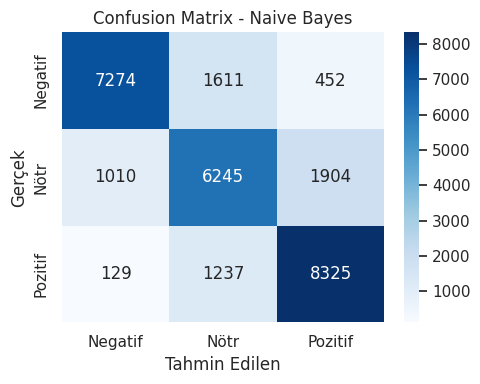


>> Logistic Regression eğitiliyor...
Accuracy: 0.7730 | Macro F1: 0.7713 | Süre: 22.88 sn
              precision    recall  f1-score   support

    Negative       0.83      0.81      0.82      9337
     Neutral       0.68      0.67      0.68      9159
    Positive       0.80      0.84      0.82      9691

    accuracy                           0.77     28187
   macro avg       0.77      0.77      0.77     28187
weighted avg       0.77      0.77      0.77     28187



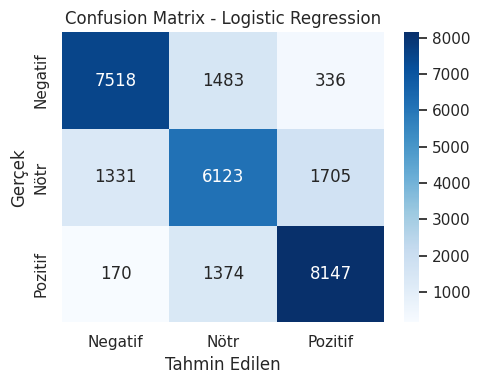


>> SVM eğitiliyor...
Accuracy: 0.7684 | Macro F1: 0.7663 | Süre: 12.03 sn
              precision    recall  f1-score   support

    Negative       0.83      0.80      0.82      9337
     Neutral       0.68      0.65      0.67      9159
    Positive       0.79      0.84      0.82      9691

    accuracy                           0.77     28187
   macro avg       0.77      0.77      0.77     28187
weighted avg       0.77      0.77      0.77     28187



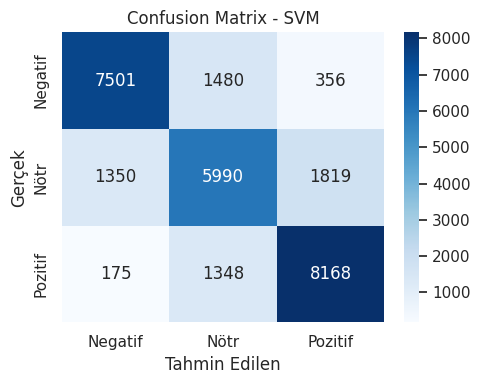

In [16]:
import time
import numpy as np
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.metrics import (
    accuracy_score, precision_recall_fscore_support,
    classification_report, confusion_matrix,
)

LABEL_NAMES = ["Negative", "Neutral", "Positive"]
LABEL_NAMES_TR = {"Negative": "Negatif", "Neutral": "Nötr", "Positive": "Pozitif"}

models = {
    "Naive Bayes": MultinomialNB(),
    "Logistic Regression": LogisticRegression(max_iter=1000, C=5),
    "SVM": LinearSVC(C=1.0, max_iter=5000),
}

results = []
trained_models = {}

for name, model in models.items():
    print(f"\n>> {name} eğitiliyor...")
    t0 = time.time()
    model.fit(X_train, y_train)
    train_time = time.time() - t0
    y_pred = model.predict(X_test)

    acc = accuracy_score(y_test, y_pred)
    precision, recall, f1, _ = precision_recall_fscore_support(y_test, y_pred, average="macro", zero_division=0)
    w_precision, w_recall, w_f1, _ = precision_recall_fscore_support(y_test, y_pred, average="weighted", zero_division=0)

    print(f"Accuracy: {acc:.4f} | Macro F1: {f1:.4f} | Süre: {train_time:.2f} sn")
    print(classification_report(y_test, y_pred, target_names=LABEL_NAMES, zero_division=0))

    cm = confusion_matrix(y_test, y_pred, labels=[0, 1, 2])
    plt.figure(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=[LABEL_NAMES_TR[l] for l in LABEL_NAMES],
                yticklabels=[LABEL_NAMES_TR[l] for l in LABEL_NAMES])
    plt.title(f"Confusion Matrix - {name}")
    plt.xlabel("Tahmin Edilen"); plt.ylabel("Gerçek")
    plt.tight_layout()
    plt.show()

    results.append({
        "model": name, "accuracy": acc, "macro_precision": precision,
        "macro_recall": recall, "macro_f1": f1,
        "weighted_precision": w_precision, "weighted_recall": w_recall,
        "weighted_f1": w_f1, "train_time_sec": round(train_time, 2),
    })
    trained_models[name] = model

,model,accuracy,macro_precision,macro_recall,macro_f1,weighted_precision,weighted_recall,weighted_f1,train_time_sec
0,Naive Bayes,0.7750,0.7769,0.7733,0.7737,0.7775,0.7750,0.7748,0.02
1,Logistic Regression,0.7730,0.7717,0.7715,0.7713,0.7726,0.7730,0.7725,22.88
2,SVM,0.7684,0.7667,0.7667,0.7663,0.7675,0.7684,0.7675,12.03


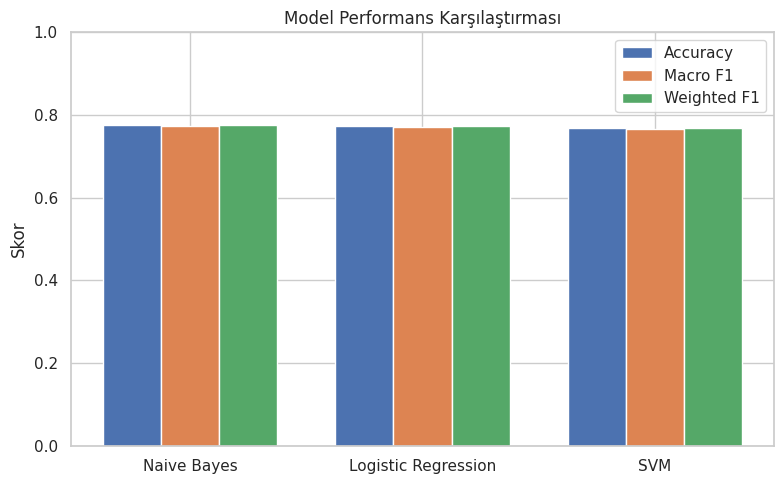


En iyi model (Macro F1'e göre): Naive Bayes


In [17]:
results_df = pd.DataFrame(results).sort_values("macro_f1", ascending=False)
display(results_df.round(4))

x = np.arange(len(results_df))
width = 0.25
plt.figure(figsize=(8, 5))
plt.bar(x - width, results_df["accuracy"], width, label="Accuracy")
plt.bar(x, results_df["macro_f1"], width, label="Macro F1")
plt.bar(x + width, results_df["weighted_f1"], width, label="Weighted F1")
plt.xticks(x, results_df["model"])
plt.ylim(0, 1)
plt.ylabel("Skor")
plt.title("Model Performans Karşılaştırması")
plt.legend()
plt.tight_layout()
plt.show()

best_name = results_df.iloc[0]["model"]
best_model = trained_models[best_name]
print(f"\nEn iyi model (Macro F1'e göre): {best_name}")

## 6. İnteraktif Demo

Üretilen modellerin çıkarım (inference) yeteneklerini çalışma zamanı içerisinde doğrulamak adına ipywidgets mimarisiyle prototipleme yapılmıştır.

In [18]:
import ipywidgets as widgets
from IPython.display import display, clear_output, HTML

LABEL_TR = {0: "Negatif", 1: "Nötr", 2: "Pozitif"}
LABEL_EMOJI = {0: "😠", 1: "😐", 2: "😊"}
LABEL_COLOR = {0: "#e74c3c", 1: "#f1c40f", 2: "#2ecc71"}

model_dropdown = widgets.Dropdown(options=list(trained_models.keys()), value=best_name, description="Model:")
text_input = widgets.Textarea(
    value="Kargo çok hızlı geldi, ürün de tam beklediğim gibiydi, teşekkürler!",
    description="Metin:", layout=widgets.Layout(width="600px", height="80px")
)
button = widgets.Button(description="Duyguyu Analiz Et", button_style="danger")
output = widgets.Output()


def on_click(b):
    with output:
        clear_output()
        text = text_input.value
        cleaned = clean_text(text)
        if not cleaned.strip():
            print("Lütfen anlamlı bir metin girin.")
            return
        model = trained_models[model_dropdown.value]
        X = vectorizer.transform([cleaned])
        pred = model.predict(X)[0]
        label, emoji, color = LABEL_TR[pred], LABEL_EMOJI[pred], LABEL_COLOR[pred]
        display(HTML(
            f"<div style='padding:15px;border-radius:10px;background-color:{color}22;"
            f"border:2px solid {color};text-align:center;width:400px;'>"
            f"<h2 style='color:{color};margin:0;'>{emoji} {label}</h2></div>"
        ))
        if hasattr(model, "predict_proba"):
            proba = dict(zip(model.classes_, model.predict_proba(X)[0]))
            proba_df = pd.DataFrame(
                {"Sınıf": [LABEL_TR[c] for c in proba.keys()], "Olasılık": list(proba.values())}
            ).sort_values("Olasılık", ascending=False)
            display(proba_df)
        print(f"\nTemizlenmiş metin: {cleaned}")


button.on_click(on_click)
display(model_dropdown, text_input, button, output)

Dropdown(description='Model:', options=('Naive Bayes', 'Logistic Regression', 'SVM'), value='Naive Bayes')

Textarea(value='Kargo çok hızlı geldi, ürün de tam beklediğim gibiydi, teşekkürler!', description='Metin:', la…

Button(button_style='danger', description='Duyguyu Analiz Et', style=ButtonStyle())

Output()

## 7. Streamlit Arayüzü (Colab'da Çalıştırma)

Colab, kalıcı bir web sunucusunu doğrudan tarayıcınıza açamaz; bu yüzden
Streamlit uygulamasını arka planda başlatıp **localtunnel** ile dışarıya
açacağız (ngrok'un aksine hesap/token gerektirmez).

**Adımlar:**
1. Aşağıdaki hücreleri sırayla çalıştırın.
2. Son hücre size bir link (`https://xxxx.loca.lt`) ve bir **Tunnel
   Password** (IP adresi) verecek.
3. Linke tıklayın, açılan sayfada "Click to Continue" derse IP adresini
   password kutusuna yapıştırın.
4. Uygulamayı durdurmak için hücreyi durdurun (⏹️) veya çalışma zamanını
   yeniden başlatın.



In [19]:
import os
import json
import joblib

os.makedirs("/content/models", exist_ok=True)

joblib.dump(vectorizer, "/content/models/tfidf_vectorizer.joblib")
for name, model in trained_models.items():
    safe_name = name.lower().replace(" ", "_")
    joblib.dump(model, f"/content/models/{safe_name}.joblib")

meta = {
    "best_model": best_name,
    "model_files": {name: f"{name.lower().replace(' ', '_')}.joblib" for name in trained_models},
}
with open("/content/models/metadata.json", "w", encoding="utf-8") as f:
    json.dump(meta, f, ensure_ascii=False, indent=2)

print("Modeller /content/models altına kaydedildi:")
print(os.listdir("/content/models"))

Modeller /content/models altına kaydedildi:
['naive_bayes.joblib', 'svm.joblib', 'tfidf_vectorizer.joblib', 'metadata.json', 'logistic_regression.joblib']


In [20]:
%%writefile /content/app.py
import json
import re
from pathlib import Path

import joblib
import pandas as pd
import streamlit as st
import nltk
from nltk.corpus import stopwords

try:
    nltk.data.find("corpora/stopwords")
except LookupError:
    nltk.download("stopwords")

MODELS_DIR = Path("/content/models")

st.set_page_config(page_title="Türkçe Duygu Analizi", page_icon="🇹🇷", layout="wide")

BASE_STOPWORDS = set(stopwords.words("turkish"))
EXTRA_STOPWORDS = {
    "bir", "de", "da", "ki", "mi", "mı", "mu", "mü", "çok", "daha", "en",
    "gibi", "ile", "için", "ve", "veya", "ya", "ama", "fakat", "ancak",
    "bu", "şu", "o", "her", "hiç", "tüm", "kadar", "diye", "acaba",
    "belki", "yani", "işte", "artık", "yine", "bile", "üzere",
}
TURKISH_STOPWORDS = BASE_STOPWORDS | EXTRA_STOPWORDS

_URL_RE = re.compile(r"https?://\S+|www\.\S+")
_EMAIL_RE = re.compile(r"\S+@\S+")
_MENTION_HASHTAG_RE = re.compile(r"[@#]\w+")
_NON_TURKISH_LETTER_RE = re.compile(r"[^a-zçğıöşü\s]")
_MULTI_SPACE_RE = re.compile(r"\s+")


def turkish_lower(text):
    text = text.replace("İ", "i").replace("I", "ı")
    return text.lower()


def clean_text(text, remove_stopwords=True, min_word_len=2):
    if not isinstance(text, str):
        return ""
    text = turkish_lower(text)
    text = _URL_RE.sub(" ", text)
    text = _EMAIL_RE.sub(" ", text)
    text = _MENTION_HASHTAG_RE.sub(" ", text)
    text = _NON_TURKISH_LETTER_RE.sub(" ", text)
    text = _MULTI_SPACE_RE.sub(" ", text).strip()
    tokens = text.split()
    tokens = [t for t in tokens if len(t) >= min_word_len]
    if remove_stopwords:
        tokens = [t for t in tokens if t not in TURKISH_STOPWORDS]
    return " ".join(tokens)


LABEL_TR = {0: "Negatif", 1: "Nötr", 2: "Pozitif"}
LABEL_EMOJI = {0: "😠", 1: "😐", 2: "😊"}
LABEL_COLOR = {0: "#e74c3c", 1: "#f1c40f", 2: "#2ecc71"}


@st.cache_resource
def load_artifacts():
    vectorizer = joblib.load(MODELS_DIR / "tfidf_vectorizer.joblib")
    meta = json.loads((MODELS_DIR / "metadata.json").read_text(encoding="utf-8"))
    models = {}
    for name, filename in meta["model_files"].items():
        path = MODELS_DIR / filename
        if path.exists():
            models[name] = joblib.load(path)
    return vectorizer, models, meta


def predict(text, vectorizer, model):
    cleaned = clean_text(text)
    if not cleaned.strip():
        return None, None, cleaned
    X = vectorizer.transform([cleaned])
    pred = model.predict(X)[0]
    proba = None
    if hasattr(model, "predict_proba"):
        proba = dict(zip(model.classes_, model.predict_proba(X)[0]))
    return pred, proba, cleaned


def main():
    st.title("🇹🇷 Türkçe Metin Duygu Analizi Sistemi")
    st.caption("Yapay Zeka Staj Projesi — Google Colab üzerinden çalıştırılıyor")

    if not (MODELS_DIR / "tfidf_vectorizer.joblib").exists():
        st.error("Model dosyaları bulunamadı. Önce notebook'taki model eğitimi ve kaydetme hücrelerini çalıştırın.")
        return

    vectorizer, models, meta = load_artifacts()

    st.subheader("Metin Duygu Tahmini")
    col1, col2 = st.columns([3, 1])
    with col1:
        text = st.text_area(
            "Metninizi girin:",
            value="Kargo çok hızlı geldi, ürün de tam beklediğim gibiydi, teşekkürler!",
            height=120,
        )
    with col2:
        available_models = list(models.keys())
        default_idx = available_models.index(meta["best_model"]) if meta["best_model"] in available_models else 0
        model_name = st.selectbox("Model seçin:", available_models, index=default_idx)
        if meta["best_model"] == model_name:
            st.caption("⭐ En iyi performanslı model")

    if st.button("Duyguyu Analiz Et", type="primary"):
        if not text.strip():
            st.warning("Lütfen bir metin girin.")
        else:
            pred, proba, cleaned = predict(text, vectorizer, models[model_name])
            if pred is None:
                st.warning("Temizleme sonrası metin boş kaldı.")
            else:
                label, emoji, color = LABEL_TR[pred], LABEL_EMOJI[pred], LABEL_COLOR[pred]
                st.markdown(
                    f"<div style='padding:20px;border-radius:10px;background-color:{color}22;"
                    f"border:2px solid {color};text-align:center;'>"
                    f"<h2 style='color:{color};margin:0;'>{emoji} {label}</h2></div>",
                    unsafe_allow_html=True,
                )
                if proba:
                    proba_df = pd.DataFrame(
                        {"Sınıf": [LABEL_TR[c] for c in proba.keys()], "Olasılık": list(proba.values())}
                    ).sort_values("Olasılık", ascending=False)
                    st.bar_chart(proba_df.set_index("Sınıf"))
                with st.expander("Temizlenmiş metin"):
                    st.code(cleaned if cleaned else "(boş)")


if __name__ == "__main__":
    main()

Overwriting /content/app.py


In [21]:
!pip install -q streamlit

In [22]:
# Tunnel password olarak kullanılacak IP adresini yazdır
print("Tunnel Password (IP adresi) - açılan sayfada bunu kullanın:")
!wget -q -O - ipv4.icanhazip.com

Tunnel Password (IP adresi) - açılan sayfada bunu kullanın:
34.74.234.45


In [24]:
# Streamlit'i arka planda başlat, sonra localtunnel ile dışarıya aç.
# Bu hücre çalışırken duracak gibi görünür (tünel açık kaldığı sürece) —
# bu normaldir. Uygulamayı kapatmak için hücreyi durdurun (⏹️).
get_ipython().system_raw("streamlit run /content/app.py --server.port 8501 --server.headless true &")
!npx --yes localtunnel --port 8501

⠙⠹⠸⠼⠴⠦⠧⠇⠏⠋⠙⠹your url is: https://red-carrots-ring.loca.lt
^C
